# EXPERIMENTO 1

Testar primeira versão da GAN integrada ao projeto e verificar quais melhores hiperparâmetros com validação pelo plot do KNN

## Imports

In [ ]:
import sys
from pathlib import Path

# Define pasta raiz do projeto
ROOT = Path.cwd().parent
sys.path.append(str(ROOT / "src"))

DATA_LABELED = ROOT / "data" / "labeled"
EXTRA = ROOT / "extra"

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# módulos do projeto
from preprocessing import load_raw, prep_data 
from knn import set_train_test, knn_predict, plot_diagram
from gan import run_experiment  


## Carregando dataset

In [3]:

df_H1 = pd.read_csv(f"{DATA_LABELED}/H1_labeled.csv")
df_H2 = pd.read_csv(f"{DATA_LABELED}/H2_labeled.csv")
df_H3 = pd.read_csv(f"{DATA_LABELED}/H3_labeled.csv")

# Curvas teóricas para o plot (iguais às do seu knn.py)
df_H1_theory = pd.read_csv(f"{EXTRA}/pontos_plot_XXZ.csv", header=None)
df_H2_theory = pd.read_csv(f"{EXTRA}/data_paper_ferro_bond.csv", header=None)
df_H3_theory = pd.DataFrame({0: [0.25, 0.5, 1.25, 1.75], 1: [0, 0, 0, 0]})

theoretical_list = [df_H1_theory, df_H2_theory, df_H3_theory]


## Função utilitária: avaliar e plotar

In [ ]:
from sklearn.metrics import accuracy_score, classification_report 

def avalia_e_plota(X_train, y_train, X_test, y_test, params_test, k, h_idx, titulo, theoretical_list):

    y_pred = knn_predict(X_train, y_train, X_test, k) 

    print(titulo)
    print("Acurácia:", accuracy_score(y_test, y_pred))
    print("=== RELATÓRIO ===")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("=== FIM ===")

    plt.figure(figsize=(6,5))
    plot_diagram(params_test, y_pred, h_idx, theoretical_list)  # usa sua função
    plt.title(f"{titulo} — K={k}")
    plt.show()


## Escolha do hamiltoniano de teste


Shapes (baseline, sem GAN):
X_train: (30424, 25) y_train: (30424,)
X_test:  (6397, 25) y_test:  (6397,)
Baseline (sem GAN)
Acurácia: 0.6957949038611849
=== RELATÓRIO ===
              precision    recall  f1-score   support

           0       0.54      0.88      0.67       478
           2       0.95      1.00      0.97       798
           3       1.00      0.38      0.55      2883
           5       0.53      0.94      0.67       985
           6       0.71      0.97      0.82      1253
           7       0.00      0.00      0.00         0

    accuracy                           0.70      6397
   macro avg       0.62      0.69      0.61      6397
weighted avg       0.83      0.70      0.68      6397

=== FIM ===


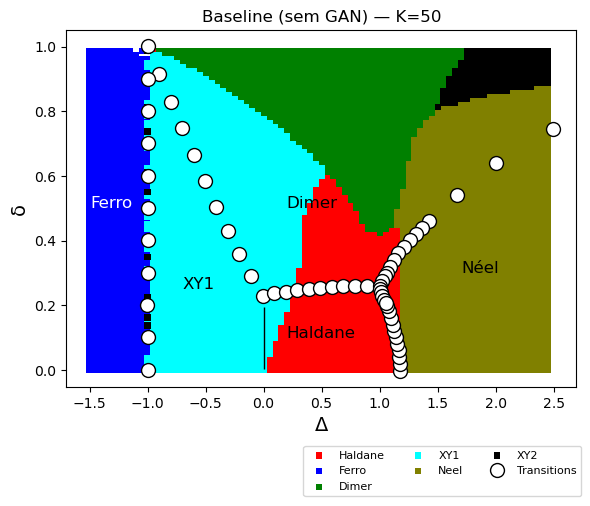

In [5]:
# Escolha qual Hamiltoniano será o de TESTE (1→H1, 2→H2, 3→H3)
H_idx_test = 2  

H_list = [df_H1, df_H2, df_H3]
# set_train_test já chama prep_data (com balanceamento RandomOverSampler + spatial sign), e filtra fases inexistentes
X_train, y_train, X_test, y_test, params_test = set_train_test(H_list, H_idx_test)

print("Shapes (baseline, sem GAN):")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)

# Baseline KNN
K = 50 
avalia_e_plota(
    X_train, y_train, X_test, y_test, params_test,
    k=K, h_idx=H_idx_test, titulo="Baseline (sem GAN)", theoretical_list=theoretical_list
)


## Aumento com cGAN + reavaliação

In [ ]:
# Configurações de hiperparâmetros da GAN 
gan_cfg = {
    "EPOCHS": 100,            
    "BATCH_SIZE": 80,
    "LATENT_DIM": 64,
    "LR": 2e-4,
    "SEED": 42,
    "SAMPLES_PER_LABEL": 500,  # por classe gerada
}

# Treina cGAN e gera dataset sintético no espaço já normalizado (X_train, y_train)
gan_out = run_experiment(gan_cfg, X_train, y_train, save_csv=True)
X_aug, y_aug = gan_out["X_aug"], gan_out["y_aug"]

print("CSV sintético:", gan_out["synthetic_csv"])
print("Checkpoints:", gan_out["checkpoints"])
print("Shapes com aumento:")
print("X_aug:", X_aug.shape, "y_aug:", y_aug.shape)


Epoch 001 | D_loss 0.6625 | G_loss 0.7319
Epoch 002 | D_loss 0.6572 | G_loss 0.7413
Epoch 003 | D_loss 0.6757 | G_loss 0.7180
Epoch 004 | D_loss 0.6736 | G_loss 0.7205
Epoch 005 | D_loss 0.6703 | G_loss 0.7276
Epoch 006 | D_loss 0.6713 | G_loss 0.7311
Epoch 007 | D_loss 0.6672 | G_loss 0.7360
Epoch 008 | D_loss 0.6661 | G_loss 0.7412
Epoch 009 | D_loss 0.6617 | G_loss 0.7496
Epoch 010 | D_loss 0.6599 | G_loss 0.7522
Epoch 011 | D_loss 0.6672 | G_loss 0.7495
Epoch 012 | D_loss 0.6679 | G_loss 0.7424
Epoch 013 | D_loss 0.6694 | G_loss 0.7455
Epoch 014 | D_loss 0.6675 | G_loss 0.7485
Epoch 015 | D_loss 0.6678 | G_loss 0.7463
Epoch 016 | D_loss 0.6557 | G_loss 0.7711
Epoch 017 | D_loss 0.6718 | G_loss 0.7405
Epoch 018 | D_loss 0.6645 | G_loss 0.7521
Epoch 019 | D_loss 0.6625 | G_loss 0.7545
Epoch 020 | D_loss 0.6628 | G_loss 0.7581
Epoch 021 | D_loss 0.6626 | G_loss 0.7561
Epoch 022 | D_loss 0.6685 | G_loss 0.7538
Epoch 023 | D_loss 0.6669 | G_loss 0.7519
Epoch 024 | D_loss 0.6623 | G_loss

## Plot

Com Data Augmentation (cGAN)
Acurácia: 0.6967328435204002
=== RELATÓRIO ===
              precision    recall  f1-score   support

           0       0.54      0.88      0.67       478
           2       0.93      1.00      0.97       798
           3       1.00      0.38      0.55      2883
           5       0.53      0.94      0.68       985
           6       0.71      0.97      0.82      1253
           7       0.00      0.00      0.00         0

    accuracy                           0.70      6397
   macro avg       0.62      0.69      0.61      6397
weighted avg       0.83      0.70      0.68      6397

=== FIM ===


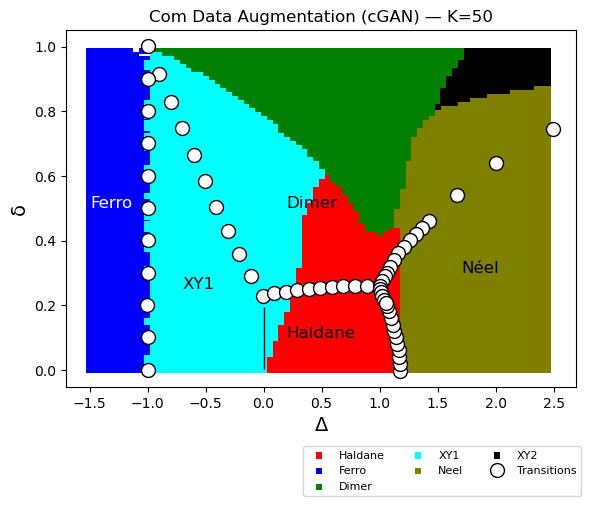

In [7]:
# KNN com aumento (real + sintético)
avalia_e_plota(
    X_aug, y_aug, X_test, y_test, params_test,
    k=K, h_idx=H_idx_test, titulo="Com Data Augmentation (cGAN)", theoretical_list=theoretical_list
)
